# Joint vs Late Fusion: Comparison

- `gemma4_predictions.csv`: columns `id, label, prob_hateful, pred`
- `late_fusion_predictions.csv`: columns `id, label, prob_text, prob_image, prob_late`

In [1]:
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Configuration

In [2]:
RESULTS_DIR = "../Results"
JOINT_CSV   = "gemma4_predictions.csv"
LATE_CSV    = "late_fusion_predictions.csv"
PLOT_OUT    = "roc_comparison.png"
SEED        = 42

## Metrics

In [ ]:
def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return {row["id"]: row for row in csv.DictReader(f)}

def auroc(y, s):
    r = stats.rankdata(s)
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    return (r[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

def roc_curve(y, s):
    order = np.argsort(-s)
    y = y[order]
    tp, fp = np.cumsum(y), np.cumsum(1 - y)
    tpr = np.concatenate([[0], tp / tp[-1]])
    fpr = np.concatenate([[0], fp / fp[-1]])
    return fpr, tpr

def bootstrap_ci(y, s, n=5000, seed=SEED):
    rng = np.random.default_rng(seed)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    vals = []
    for _ in range(n):
        idx = np.concatenate([rng.choice(pos, len(pos)), rng.choice(neg, len(neg))])
        vals.append(auroc(y[idx], s[idx]))
    return np.percentile(vals, [2.5, 97.5])

def bootstrap_diff(y, sa, sb, n=10000, seed=SEED):
    rng = np.random.default_rng(seed)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    diffs = np.empty(n)
    for b in range(n):
        idx = np.concatenate([rng.choice(pos, len(pos)), rng.choice(neg, len(neg))])
        diffs[b] = auroc(y[idx], sa[idx]) - auroc(y[idx], sb[idx])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return {"lo": lo, "hi": hi, "p_gt": float((diffs > 0).mean())}

## Load predictions

In [4]:
joint = load_csv(os.path.join(RESULTS_DIR, JOINT_CSV))
late  = load_csv(os.path.join(RESULTS_DIR, LATE_CSV))

ids = sorted(set(joint) & set(late))
assert ids, "no shared ids between the two prediction files"
for i in ids:
    assert int(joint[i]["label"]) == int(late[i]["label"]), f"label mismatch at id {i}"

y = np.array([int(joint[i]["label"]) for i in ids])
models = {
    "Gemma LoRA (joint)": np.array([float(joint[i]["prob_hateful"]) for i in ids]),
    "BERT text-only":     np.array([float(late[i]["prob_text"]) for i in ids]),
    "ViT image-only":     np.array([float(late[i]["prob_image"]) for i in ids]),
    "Late fusion (avg)":  np.array([float(late[i]["prob_late"]) for i in ids]),
}
print(f"n = {len(ids)}  |  {y.sum()} hateful / {(1 - y).sum()} not")

n = 1000  |  490 hateful / 510 not


## AUROC per model

In [5]:
rows = []
for name, s in models.items():
    lo, hi = bootstrap_ci(y, s)
    rows.append({"model": name, "AUROC": round(auroc(y, s), 4),
                 "AUROC 95% CI": f"[{lo:.3f}, {hi:.3f}]", "n": len(ids)})
pd.DataFrame(rows)

,model,AUROC,AUROC 95% CI,n
0,Gemma LoRA (joint),0.6494,"[0.615, 0.683]",1000
1,BERT text-only,0.6074,"[0.573, 0.643]",1000
2,ViT image-only,0.4810,"[0.445, 0.516]",1000
3,Late fusion (avg),0.5288,"[0.493, 0.564]",1000


## Combined ROC

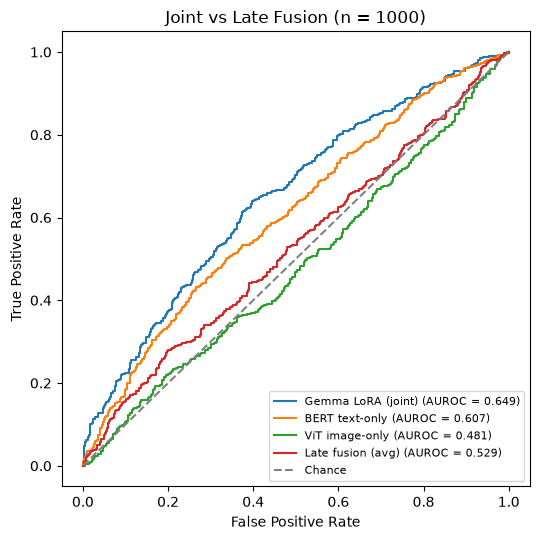

In [7]:
plt.figure(figsize=(5.5, 5.5))
for name, s in models.items():
    fpr, tpr = roc_curve(y, s)
    plt.plot(fpr, tpr, label=f"{name} (AUROC = {auroc(y, s):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Joint vs Late Fusion (n = {len(ids)})")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, PLOT_OUT), dpi=150)
plt.show()